In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [47]:
df = pd.read_csv("Cleaned_Bengaluru_House_Data.csv")

In [48]:
# Focus on locations with at least 50 listings to avoid outliers
location_counts = df['location'].value_counts()
popular_locations = location_counts[location_counts >= 50].index
df_top = df[df['location'].isin(popular_locations)]

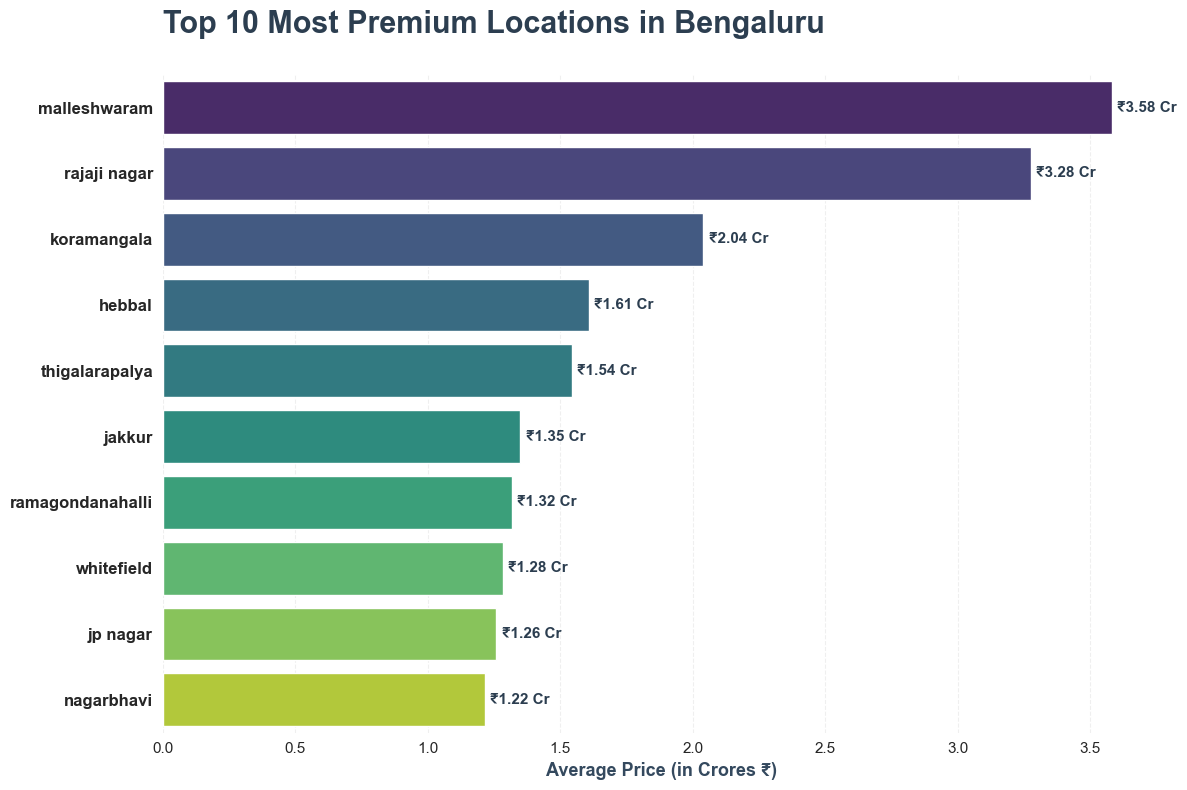

In [87]:
# top 10 expensive location 
top_10_expensive = df_top.groupby('location')['total_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8), dpi=100)

ax = sns.barplot(
    x=top_10_expensive.values / 1e7, # X-axis in Crores
    y=top_10_expensive.index,
    hue=top_10_expensive.index,
    palette="viridis",
    legend=False
)

plt.title('Top 10 Most Premium Locations in Bengaluru', 
          fontsize=22, fontweight='bold', pad=30, loc='left', color='#2c3e50')
plt.xlabel('Average Price (in Crores ₹)', fontsize=13, fontweight='bold', color='#34495e')
plt.ylabel('') # Cleaner look without the 'Location' label

for i, v in enumerate(top_10_expensive):
    # Format the label to show 2 decimal places in Crores
    label = f"₹{v/1e7:.2f} Cr"
    
    # Place text with slight padding from the end of the bar
    ax.text(v/1e7 + 0.02, i, label, color='#2c3e50', va='center', fontweight='bold', fontsize=11)

sns.despine(left=True, bottom=True)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12, fontweight='600') # Make location names bold
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

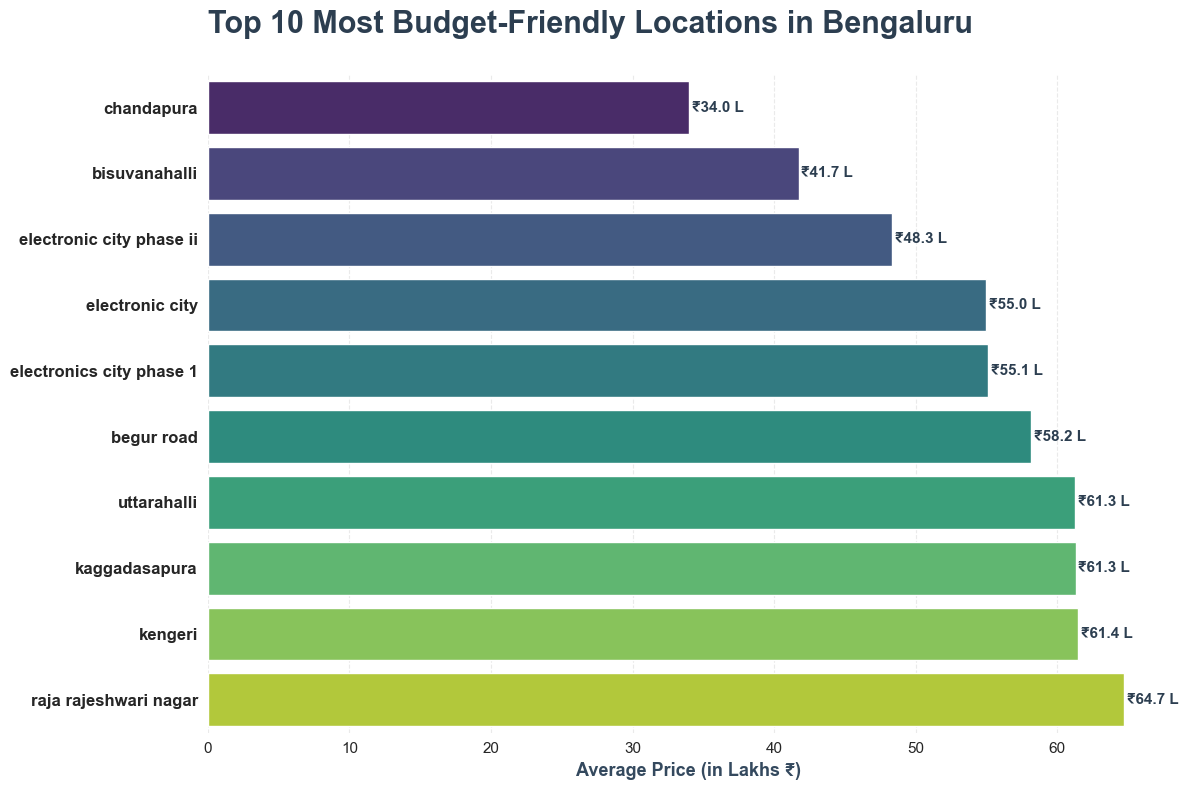

In [92]:
# top 10 cheapest locations
top_10_cheap = df_top.groupby('location')['total_price'].mean().sort_values(ascending=True).head(10)

plt.figure(figsize=(12, 8), dpi=100)

ax = sns.barplot(
    x=top_10_cheap.values / 1e5,  # Convert to Lakhs for the X-axis
    y=top_10_cheap.index,
    hue=top_10_cheap.index,
    palette="viridis", 
    legend=False
)

plt.title('Top 10 Most Budget-Friendly Locations in Bengaluru', 
          fontsize=22, fontweight='bold', pad=30, loc='left', color='#2c3e50')
plt.xlabel('Average Price (in Lakhs ₹)', fontsize=13, fontweight='bold', color='#34495e')
plt.ylabel('') # Cleaner look without the 'Location' label

for i, v in enumerate(top_10_cheap):
    # If the price is above 100 Lakhs, show it in Crores, else in Lakhs
    if v >= 1e7:
        label = f"₹{v/1e7:.2f} Cr"
    else:
        label = f"₹{v/1e5:.1f} L"
    
    ax.text(v/1e5 + 0.2, i, label, color='#2c3e50', va='center', fontweight='bold', fontsize=11)

sns.despine(left=True, bottom=True)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12, fontweight='600')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

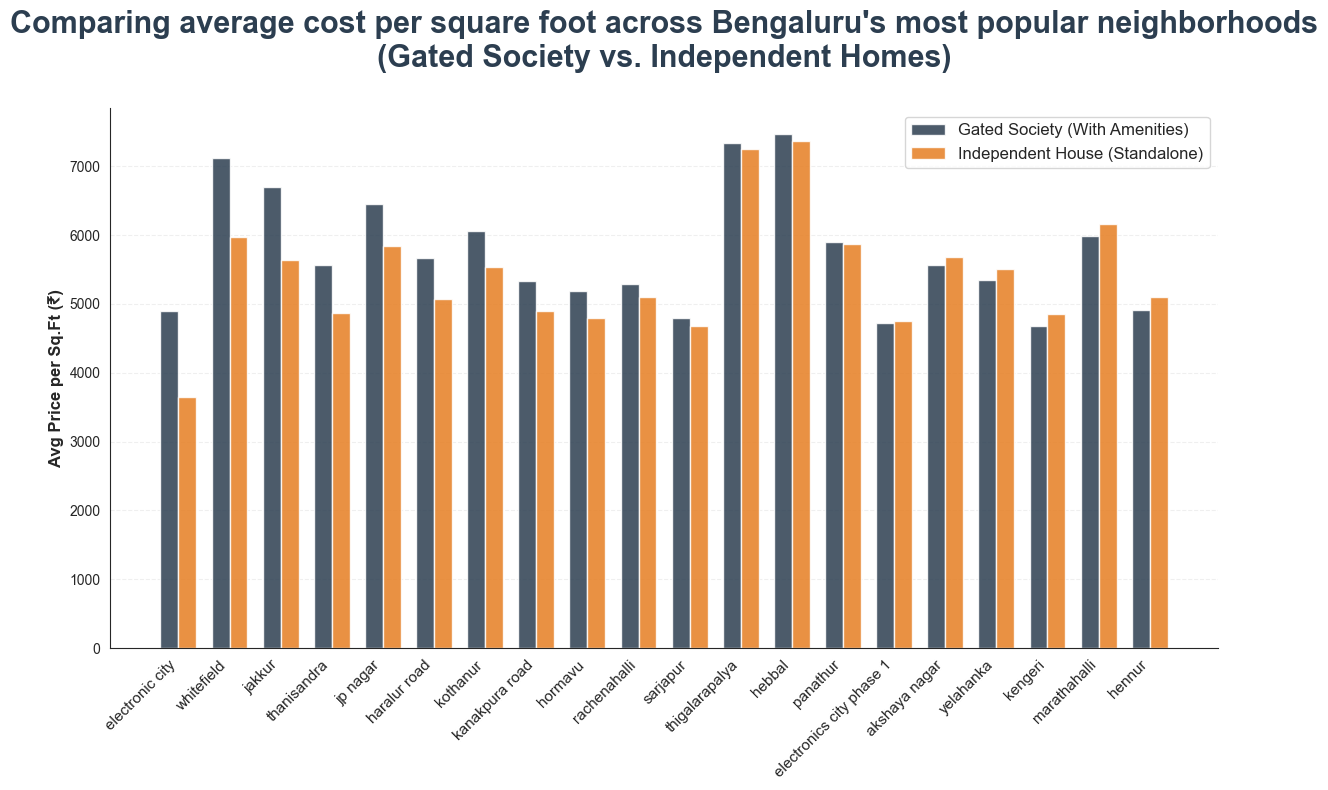

In [94]:
mask = df['society'] == "no society"
independent_df = df[mask] # No society
society_df = df[~mask]    # Has society

# Filtering independent and society data for popular locations
ind_common = independent_df[independent_df['location'].isin(popular_locations)]
soc_common = society_df[society_df['location'].isin(popular_locations)]

# calculating average price per square foot
ind_avg = ind_common.groupby('location')['price_per_sqft'].mean().reset_index()
soc_avg = soc_common.groupby('location')['price_per_sqft'].mean().reset_index()

# Merge the two dataframes on location to compare the average price per square foot
comparison_df = ind_avg.merge(soc_avg, on='location', suffixes=('_ind', '_soc'))

# Show the "Society Premium" (How much MORE societies cost)
comparison_df['premium'] = comparison_df['price_per_sqft_soc'] - comparison_df['price_per_sqft_ind']

# Sort by the highest premium to show where societies are most "exclusive"
comparison_df = comparison_df.sort_values('premium', ascending=False).head(20)

x = np.arange(len(comparison_df['location']))
width = 0.35 

plt.figure(figsize=(12, 8), dpi=100)

# Use professional, contrasting colors
plt.bar(x - width/2, comparison_df['price_per_sqft_soc'], width, 
        label='Gated Society (With Amenities)', color='#2c3e50', alpha=0.85)

plt.bar(x + width/2, comparison_df['price_per_sqft_ind'], width, 
        label='Independent House (Standalone)', color='#e67e22', alpha=0.85)

plt.xticks(x, comparison_df['location'], rotation=45, ha='right', fontsize=11)
plt.ylabel("Avg Price per Sq.Ft (₹)", fontsize=12, fontweight='bold')

plt.title("Comparing average cost per square foot across Bengaluru's most popular neighborhoods\n(Gated Society vs. Independent Homes)", 
             fontsize=22, fontweight='bold', pad=30, color='#2c3e50')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(fontsize=12, frameon=True, loc='upper right')

sns.despine() # Makes the chart look modern and open
plt.tight_layout()
plt.show()

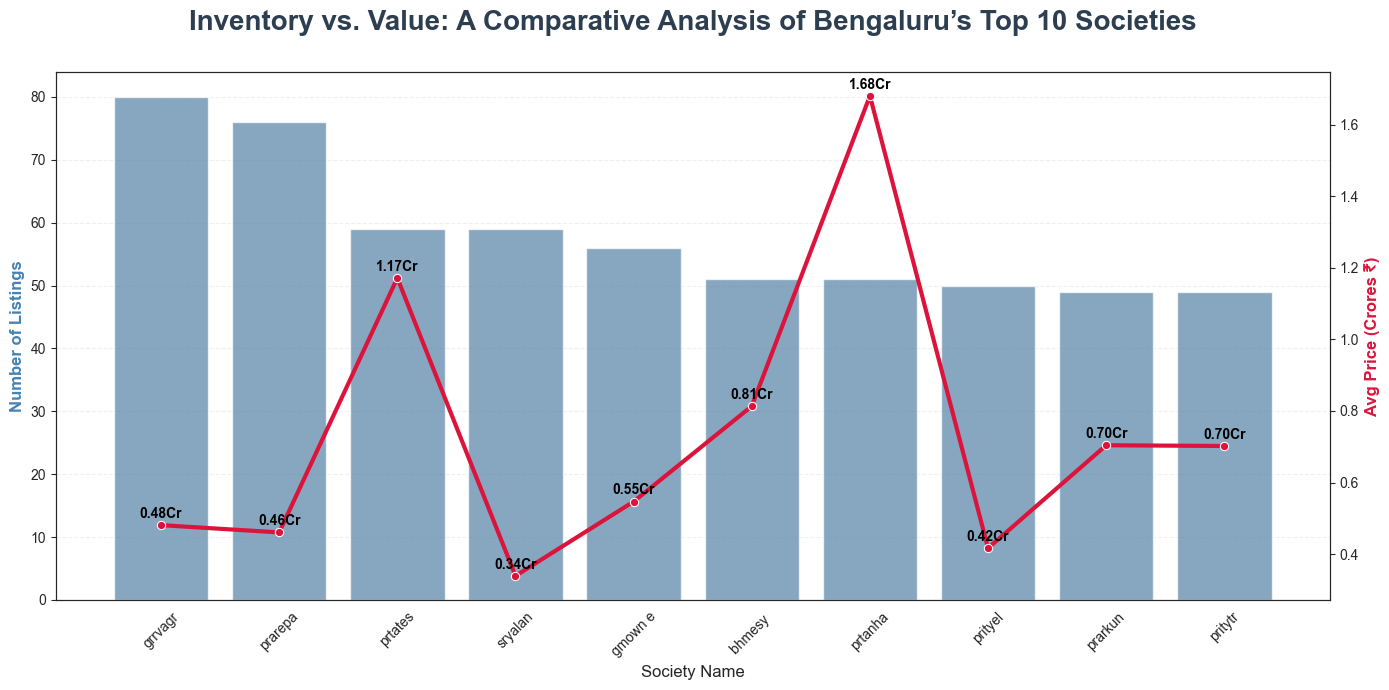

In [ ]:
top_societies = df[df['society'] != 'no society']['society'].value_counts().head(10).index
subset = df[df['society'].isin(top_societies)]

stats = subset.groupby('society').agg(
    count=('society', 'count'),
    avg_price=('total_price', 'mean')
).sort_values('count', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

# Primary Axis: Bars for Volume
sns.barplot(x=stats.index, y=stats['count'], ax=ax1, color='steelblue', alpha=0.7)
ax1.set_ylabel('Number of Listings', fontsize=12, fontweight='bold', color='steelblue')
ax1.set_xlabel('Society Name', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Secondary Axis: Line for Value
ax2 = ax1.twinx()
sns.lineplot(x=stats.index, y=stats['avg_price'] / 1e7, ax=ax2, color='crimson', marker='o', linewidth=3)
ax2.set_ylabel('Avg Price (Crores ₹)', fontsize=12, fontweight='bold', color='crimson')

# Professional Annotations
for i, v in enumerate(stats['avg_price'] / 1e7):
    ax2.text(i, v + 0.02, f'{v:.2f}Cr', color='black', fontweight='bold', ha='center', fontsize=10)

plt.title('Inventory vs. Value: A Comparative Analysis of Bengaluru’s Top 10 Societies', 
          fontsize=20, pad=30, fontweight='bold', color='#2c3e50')

ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

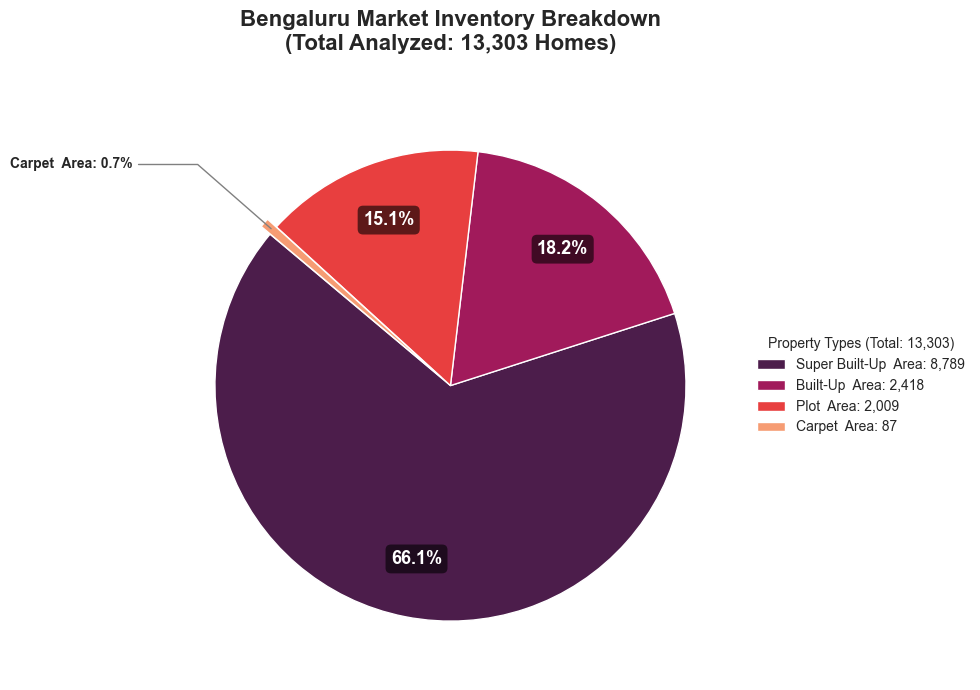

In [99]:
counts = df['area_type'].value_counts()
labels = counts.index
sizes = counts.values
total_listings = sum(sizes)

colors = sns.color_palette("rocket", len(labels))
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

# Explode only the tiny Carpet Area to highlight it
explode = [0.05 if x == 'carpet  area' else 0 for x in labels]

# Plotting with "Bbox" for small percentages
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode,
    labels=None, 
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '', # Only show % inside if large enough
    startangle=140, 
    colors=colors,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

for autotext in autotexts:
    autotext.set_fontsize(13)          # Bigger text
    autotext.set_fontweight('bold')    # Bold
    autotext.set_color('white')        # High contrast
    autotext.set_bbox(dict(            # Background for readability
        facecolor='black',
        alpha=0.6,
        edgecolor='none',
        boxstyle='round,pad=0.3'
    ))
    
# Adding Annotations for the tiny "Carpet Area" (The Fix)
for i, p in enumerate(sizes):
    percentage = 100 * p / total_listings
    if percentage < 2:  # For the tiny Carpet Area slice
        ang = (wedges[i].theta2 + wedges[i].theta1) / 2.
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        ax.annotate(f"{labels[i].title()}: {percentage:.1f}%", xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, weight='bold',
                    arrowprops=dict(arrowstyle="-", color='0.5', connectionstyle=connectionstyle))

# Legend & Total Count
ax.legend(wedges, [f"{l.title()}: {s:,}" for l, s in zip(labels, sizes)],
          title=f"Property Types (Total: {total_listings:,})",
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.title(f'Bengaluru Market Inventory Breakdown\n(Total Analyzed: {total_listings:,} Homes)', 
          fontsize=16, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

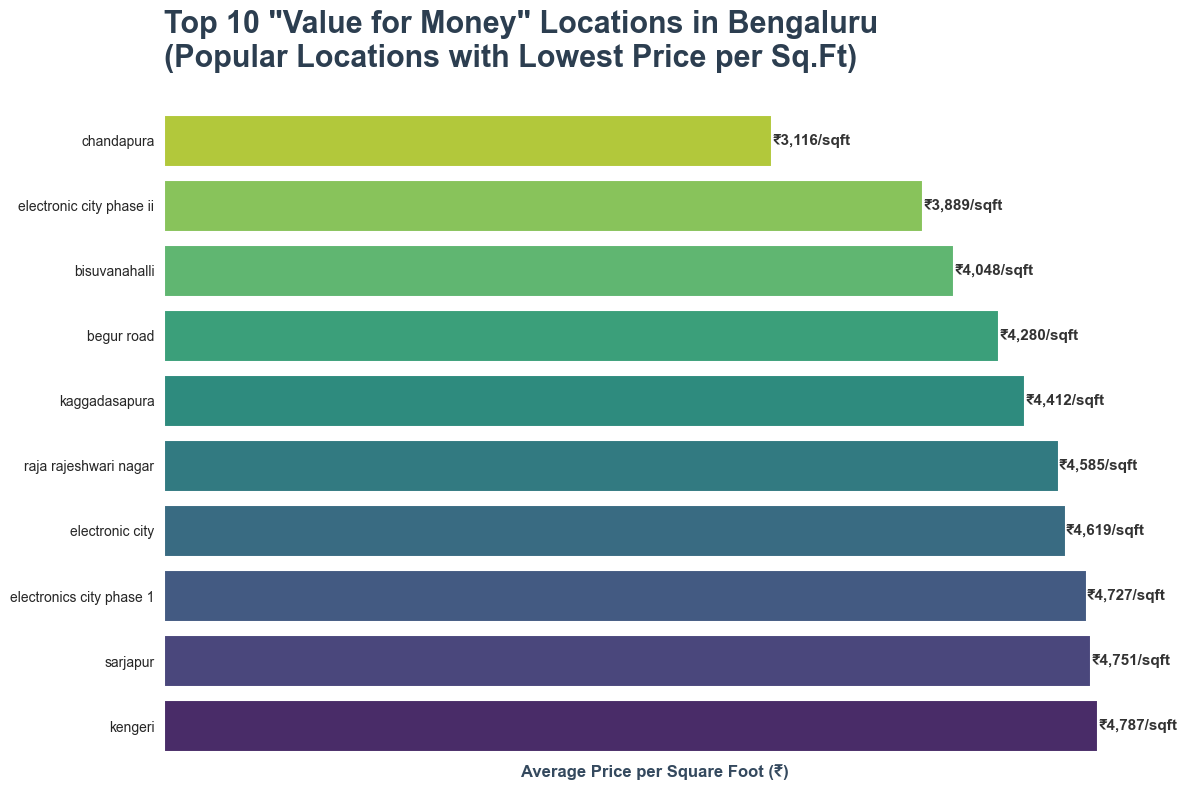

In [100]:
# Filter for locations with at least 50 listings for data reliability
loc_stats = df.groupby('location').agg(
    count=('location', 'count'),
    avg_pps=('price_per_sqft', 'mean')
).reset_index()

vfm_locations = loc_stats[loc_stats['count'] >= 50].sort_values('avg_pps').head(10)

# Create the figure
plt.figure(figsize=(12, 8), dpi=100)
sns.set_style("white") # Using white for a cleaner look than whitegrid

# Use the palette you liked (viridis_r)
colors = sns.color_palette("viridis_r", len(vfm_locations))

ax = sns.barplot(
    x='avg_pps', 
    y='location', 
    data=vfm_locations, 
    hue='location', 
    legend=False, 
    palette=colors,
    edgecolor='white',
    linewidth=1.5
)

# 1. Add Price Labels with better padding
for i, v in enumerate(vfm_locations['avg_pps']):
    ax.text(v + 1, i, f"₹{v:,.0f}/sqft", color='#333333', va='center', fontweight='bold', fontsize=11)

# 2. Modern Title and Axis Labels
plt.title('Top 10 "Value for Money" Locations in Bengaluru\n(Popular Locations with Lowest Price per Sq.Ft)', 
             fontsize=22, fontweight='bold', pad=30, loc='left', color='#2c3e50')

plt.xlabel('Average Price per Square Foot (₹)', fontsize=12, fontweight='bold', color='#34495e')
plt.ylabel('') # Remove y-label as location names are self-explanatory

# 3. Clean up the "Chart Junk"
sns.despine(left=True, bottom=True)
plt.xticks([]) # Hide x-axis numbers because we have labels on the bars
plt.tight_layout()
plt.show()